# In this lab we will do
- split datasets into training, cross validation, and test sets
- compare several `neural network` architectures

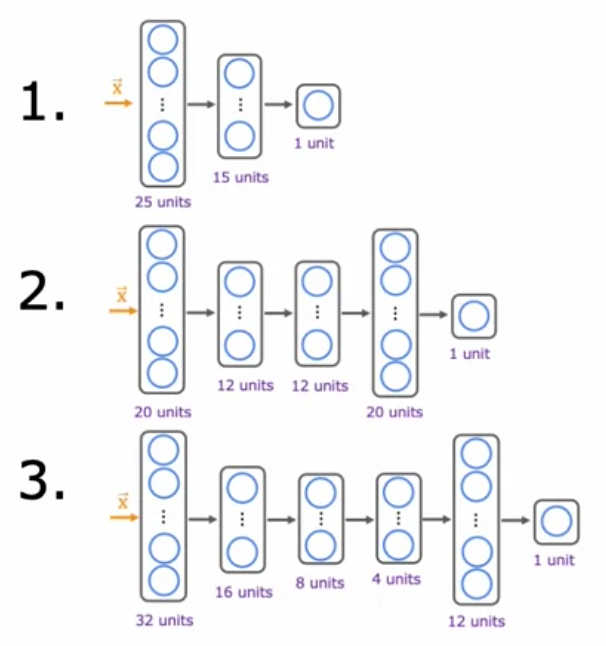

In [14]:
import numpy as np
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
# for building and training NN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# for ploting
import matplotlib.pyplot as plt
import pandas as pd

# Data

In [15]:
data = np.round(pd.read_csv(r"E:\SALEH\Data\data_w3_ex1.csv",header=None),decimals=2)
data.columns=['X','y']

In [16]:
X = data[["X"]]
y = data[["y"]]

In [17]:
print(f"the shape of the inputs x is: {X.shape}")
print(f"the shape of the targets y is: {y.shape}")

the shape of the inputs x is: (50, 1)
the shape of the targets y is: (50, 1)


### Split the data into Training set,Cross validation and Test set

- `Training set 60%`: Used to train the model
- `Cross validation 20%`: Used to choose the model hyperparameters(e.g, degree)
- `test set 20%`: Used to deliver a fair estimate of chosen model's preformance (to see the final performance)

we choose the `d`(degree) using `CV`(cross validation),then we check the `test set`, with this we get a realistic estimate of how the model generalizes to unseen data  

---
`Scikit-learn` provides a train_test_split function to split your data into the parts mentioned above




In [18]:
#60 for the training
X_train,X_,y_train,y_ = train_test_split(X,y,test_size=0.40,random_state=1)

In [19]:
# 20% for cv and test
X_cv,X_test,y_cv,y_test = train_test_split(X_,y_,test_size=0.50,random_state=1)

del X_,y_

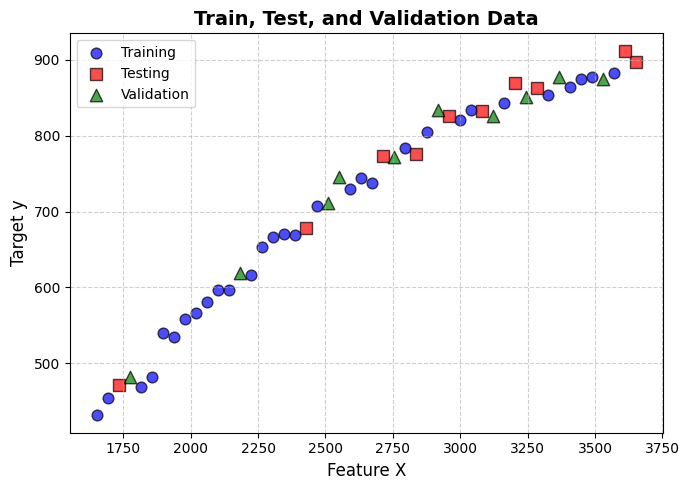

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

# Training data
plt.scatter(X_train, y_train, 
            color="blue", marker="o", s=60, alpha=0.7, 
            edgecolor="k", label="Training")

# Testing data
plt.scatter(X_test, y_test, 
            color="red", marker="s", s=70, alpha=0.7, 
            edgecolor="k", label="Testing")

# Cross-validation data
plt.scatter(X_cv, y_cv, 
            color="green", marker="^", s=80, alpha=0.7, 
            edgecolor="k", label="Validation")


plt.xlabel("Feature X", fontsize=12)
plt.ylabel("Target y", fontsize=12)
plt.title("Train, Test, and Validation Data", fontsize=14, fontweight="bold")


plt.legend(frameon=True, fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [21]:
print(f"the shape of the training set (input) is: {X_train.shape}")
print(f"the shape of the training set (target) is: {y_train.shape}\n")
print(f"the shape of the cross validation set (input) is: {X_cv.shape}")
print(f"the shape of the cross validation set (target) is: {y_cv.shape}\n")
print(f"the shape of the test set (input) is: {X_test.shape}")
print(f"the shape of the test set (target) is: {y_test.shape}")

the shape of the training set (input) is: (30, 1)
the shape of the training set (target) is: (30, 1)

the shape of the cross validation set (input) is: (10, 1)
the shape of the cross validation set (target) is: (10, 1)

the shape of the test set (input) is: (10, 1)
the shape of the test set (target) is: (10, 1)


# scaling data and adding polynomial features

In [22]:
#Apply polynomial
degree = 1
poly = PolynomialFeatures(degree,include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_cv_poly = poly.transform(X_cv)
X_test_poly = poly.transform(X_test)


#scale 
scaler = StandardScaler()
X_train_scaled_p = scaler.fit_transform(X_train_poly)
X_cv_scaled_p = scaler.transform(X_cv_poly)
X_test_scaled_p =scaler.transform(X_test_poly)

# scale the y_train
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_cv_scaled = y_scaler.transform(y_cv)

# Build and train the models

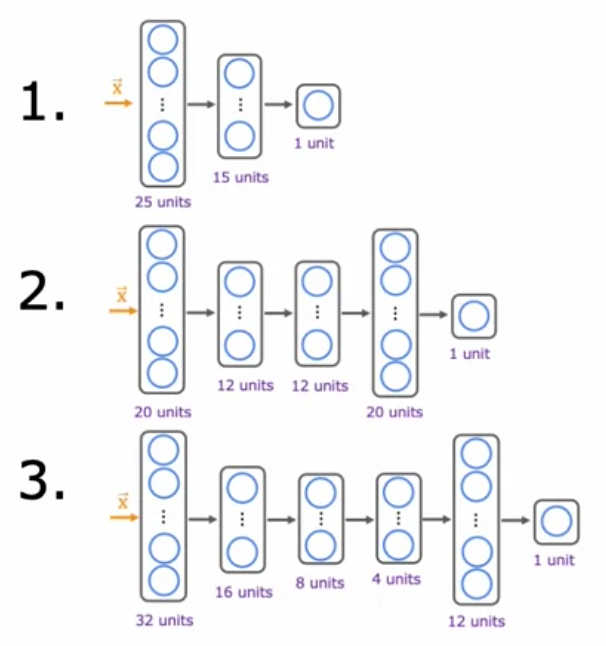

In [23]:
def build_model():
    tf.random.set_seed(20)
    Model_1 = Sequential(
        [
            Dense(25,activation='relu'),
            Dense(15,activation='relu'),
            Dense(1,activation='linear'),
        
        ],
        name='Model_1'
    )


    
    Model_2 = Sequential(
        [
            Dense(20,activation='relu'),
            Dense(12,activation='relu'),
            Dense(12,activation='relu'),
            Dense(20,activation='relu'),
            Dense(1,activation='linear'),
        ],
        name='Model_2'
    )

    Model_3 = Sequential(
        [
            Dense(32,activation='relu'),
            Dense(16,activation='relu'),
            Dense(8,activation='relu'),
            Dense(4,activation='relu'),
            Dense(12,activation='relu'),
            Dense(1,activation='linear'),
        ],
        name='Model_3'
    )

    model_list = [Model_1,Model_2,Model_3]
    return model_list

# Models training

In [27]:
# Lists
Training_MSE = []
CV_MSE = []
NN_models = build_model() 


for i, model in enumerate(NN_models):
    model.compile(
        loss='mse',
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.1)
    )
    
    print(f"Training {model.name}...")
    model.fit(X_train_scaled_p, y_train, epochs=300, verbose=0)
    print("Done.")

    
    y_train_pred = model.predict(X_train_scaled_p)
    y_cv_pred = model.predict(X_cv_scaled_p)

   
    Training_MSE.append(mean_squared_error(y_train, y_train_pred) / 2)
    CV_MSE.append(mean_squared_error(y_cv, y_cv_pred) / 2)


print("\nResult:")
for i in range(len(Training_MSE)):
    print(f"Model {i+1}: Training MSE = {Training_MSE[i]:.4f}, CV MSE = {CV_MSE[i]:.4f}")


Training Model_1...
Done.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Training Model_2...
Done.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Training Model_3...
Done.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

Result:
Model 1: Training MSE = 75.4001, CV MSE = 98.3203
Model 2: Training MSE = 73.3975, CV MSE = 112.2836
Model 3: Training MSE = 73.3975, CV MSE = 112.2770


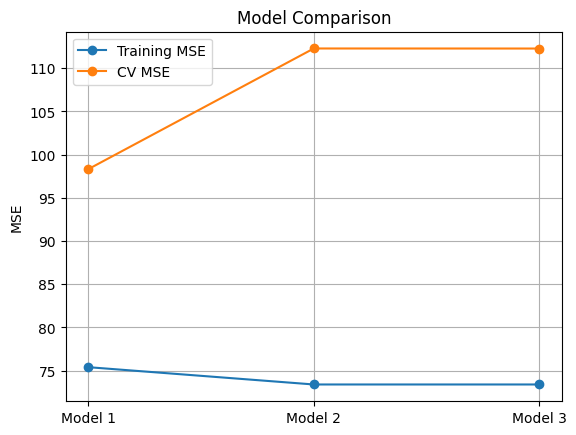

In [28]:
import matplotlib.pyplot as plt

x_labels = ['Model 1', 'Model 2', 'Model 3']
plt.plot(x_labels, Training_MSE, label='Training MSE', marker='o')
plt.plot(x_labels, CV_MSE, label='CV MSE', marker='o')
plt.ylabel('MSE')
plt.title('Model Comparison')
plt.legend()
plt.grid(True)
plt.show()


#  we chose `model_3` has lowest MSE on Training and CV sets 

In [29]:
# select the best model
Best_model = NN_models[-1]

y_hat = Best_model.predict(X_test_scaled_p)
test_MSE = mean_squared_error(y_test,y_hat)/2
print(f"Selected Model: {NN_models[-1]}")
print(f"Training MSE: {Training_MSE[-1]:.2f}")
print(f"Cross Validation MSE: {CV_MSE[-1]:.2f}")
print(f"Test MSE: {test_MSE:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Selected Model: <Sequential name=Model_3, built=True>
Training MSE: 73.40
Cross Validation MSE: 112.28
Test MSE: 132.23
